In [72]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer #text to numerical representation
from sklearn.metrics import classification_report, confusion_matrix #accuracy alone is misleading, confusion matrix  and classification report
from sklearn.linear_model import LogisticRegression #target variable has 2 class
from sklearn.metrics import accuracy_score 
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression

In [73]:
df = pd.read_csv('mail_data.csv')

In [74]:
print(df)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [75]:
data = df.where(pd.notnull(df), '') #replaces null values with empty strings

In [76]:
data.head() #top 5(or more if u specify)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [77]:
data.info() #data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 43.6+ KB


In [78]:
data.shape #columns + rows

(5572, 2)

In [79]:
data.loc[data["Category"] == 'spam', 'Category',] = 0
data.loc[data["Category"] == 'ham', 'Category',] = 1

In [80]:
X = data['Message']

Y = data['Category']

In [81]:
print(Y)

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object


In [82]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [83]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 3) #80% training, 20% testing

In [84]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(5572,)
(4457,)
(1115,)


In [85]:
print(Y.shape)
print(Y_train.shape)
print(Y_test.shape)

(5572,)
(4457,)
(1115,)


In [86]:
feature_extraction = TfidfVectorizer(min_df = 1, stop_words = 'english', lowercase = True) #converts raw email text into numbers so that model understands

X_train_features = feature_extraction.fit_transform(X_train) #fit learns the vocab (what words exist, how frequent); #transform converts emails into numeric vectors based on vocab
X_test_features = feature_extraction.transform(X_test) #transform test data learnt from training


Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

In [87]:
print (X_train)

3075                  Don know. I did't msg him recently.
1787    Do you know why god created gap between your f...
1614                         Thnx dude. u guys out 2nite?
4304                                      Yup i'm free...
3266    44 7732584351, Do you want a New Nokia 3510i c...
                              ...                        
789     5 Free Top Polyphonic Tones call 087018728737,...
968     What do u want when i come back?.a beautiful n...
1667    Guess who spent all last night phasing in and ...
3321    Eh sorry leh... I din c ur msg. Not sad alread...
1688    Free Top ringtone -sub to weekly ringtone-get ...
Name: Message, Length: 4457, dtype: object


In [88]:
model = LogisticRegression() #creates the model(knows the algorithm)

In [89]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB()
}
print(X_train_features) #numerical features
for name, m in models.items():
    m.fit(X_train_features, Y_train)
    preds = m.predict(X_test_features)
    print(f"\n--- {name} ---")
    print(classification_report(Y_test, preds))
    print(X_train_features) #numerical features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34775 stored elements and shape (4457, 7431)>
  Coords	Values
  (0, 2329)	0.38783870336935383
  (0, 3811)	0.34780165336891333
  (0, 2224)	0.413103377943378
  (0, 4456)	0.4168658090846482
  (0, 5413)	0.6198254967574347
  (1, 3811)	0.17419952275504033
  (1, 3046)	0.2503712792613518
  (1, 1991)	0.33036995955537024
  (1, 2956)	0.33036995955537024
  (1, 2758)	0.3226407885943799
  (1, 1839)	0.2784903590561455
  (1, 918)	0.22871581159877646
  (1, 2746)	0.3398297002864083
  (1, 2957)	0.3398297002864083
  (1, 3325)	0.31610586766078863
  (1, 3185)	0.29694482957694585
  (1, 4080)	0.18880584110891163
  (2, 6601)	0.6056811524587518
  (2, 2404)	0.45287711070606745
  (2, 3156)	0.4107239318312698
  (2, 407)	0.509272536051008
  (3, 7414)	0.8100020912469564
  (3, 2870)	0.5864269879324768
  (4, 2870)	0.41872147309323743
  (4, 487)	0.2899118421746198
  :	:
  (4454, 2855)	0.47210665083641806
  (4454, 2246)	0.47210665083641806
  (4455, 4456)	0.24

In [90]:
model.fit(X_train_features, Y_train) #trains the model + sees features labels (learns patterns)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [91]:
prediction_on_training_data = model.predict(X_train_features) #actually predicts
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data) #% of emails guessed correctly

In [92]:
print ('accuracy on training data: ', accuracy_on_training_data)

Acc on training data:  0.9676912721561588


In [93]:
prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)

In [94]:
print('accuracy on test data: ', accuracy_on_test_data)

acc on test data:  0.9668161434977578


In [95]:
input_your_mail = [""]
input_data_features = feature_extraction.transform(input_your_mail)

prediction=model.predict(input_data_features)
print(prediction)

if(prediction[0]==1):
    print('Ham mail')

else:
    print('Spam mail')

[1]
Ham mail


In [96]:
print(classification_report(Y_test, prediction_on_test_data))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86       155
           1       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [97]:
pickle.dump(model, open('spam_model.pkl', 'wb'))
pickle.dump(feature_extraction, open('vectorizer.pkl', 'wb'))

In [98]:
scores = cross_val_score(model, X_train_features, Y_train, cv=5)
print("individual fold scores:", scores)
print("average accuracy:", scores.mean())

Individual fold scores: [0.93609865 0.93834081 0.94163861 0.94276094 0.94276094]
Average accuracy: 0.9403199911421138


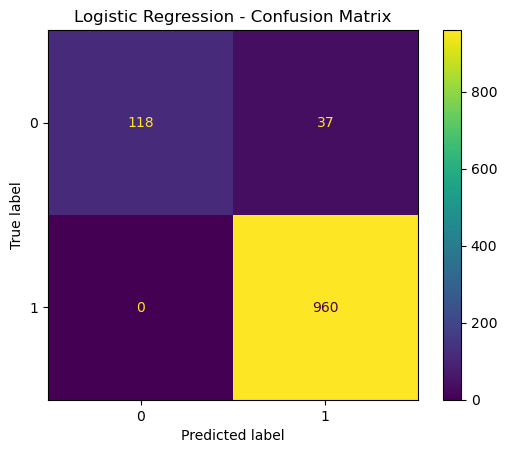

In [99]:
ConfusionMatrixDisplay.from_predictions(Y_test, prediction_on_test_data)
plt.title("logistic regression - confusion matrix")
plt.show()